In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Load predictions
df = pd.read_csv("predictions.csv")

1. training & validation loss 

In [3]:
import torch

ckpt = torch.load("20260131_061615_HierarchicalAttnMIL_epoch30.pth", map_location="cpu")

print(type(ckpt))
print(ckpt.keys() if isinstance(ckpt, dict) else "Not a dict")

<class 'dict'>
dict_keys(['arch', 'model_state_dict', 'epoch', 'optimizer_state_dict', 'train_losses', 'val_losses', 'val_accuracies', 'learning_rates', 'best_val_loss', 'scheduler_state_dict'])


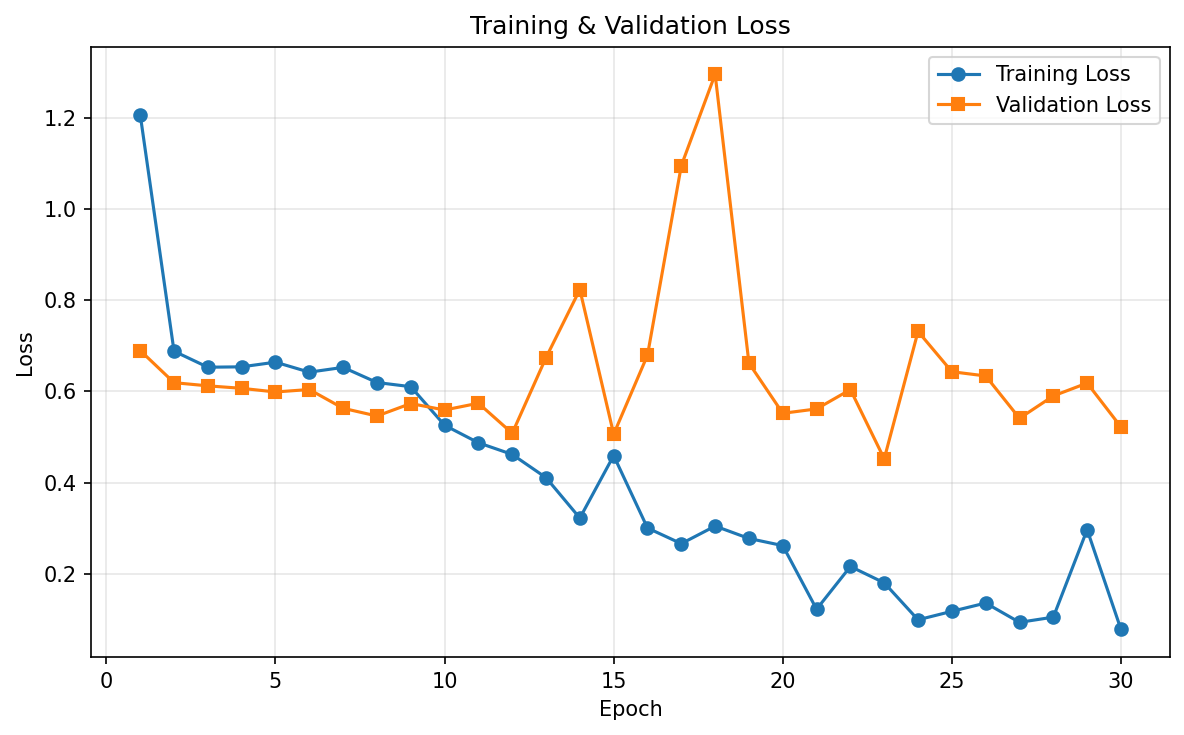

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# load checkpoint
ckpt = torch.load("20260131_061615_HierarchicalAttnMIL_epoch30.pth", map_location="cpu")

train_losses = ckpt["train_losses"]
val_losses = ckpt["val_losses"]

epochs = np.arange(1, len(train_losses)+1)

# plot
plt.figure(figsize=(8,5), dpi=150)

plt.plot(epochs, train_losses, marker='o', label="Training Loss")
plt.plot(epochs, val_losses, marker='s', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


2) confusion matrix 

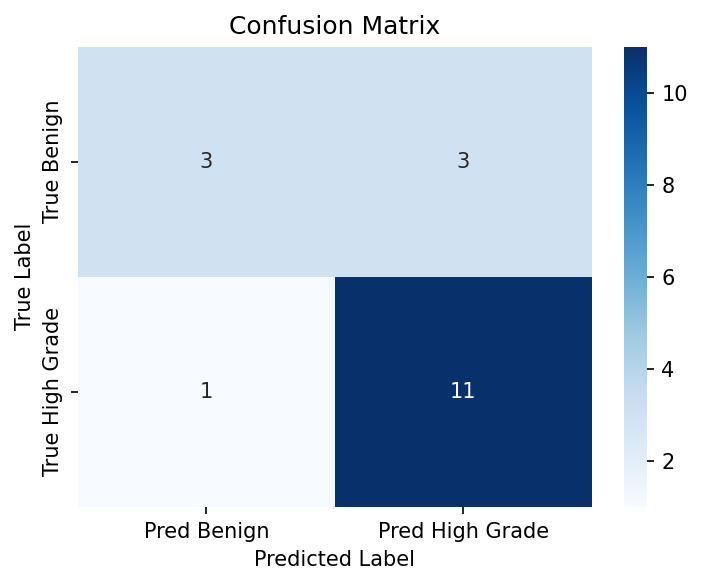

In [5]:
# confusion matrix 
threshold = 0.5
df["pred_label"] = (df["prob_high_grade"] >= threshold).astype(int)

cm = confusion_matrix(df["true_label"], df["pred_label"])

plt.figure(figsize=(5,4), dpi=150)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Benign", "Pred High Grade"],
    yticklabels=["True Benign", "True High Grade"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

3) deviation plot (true vs probabilities)


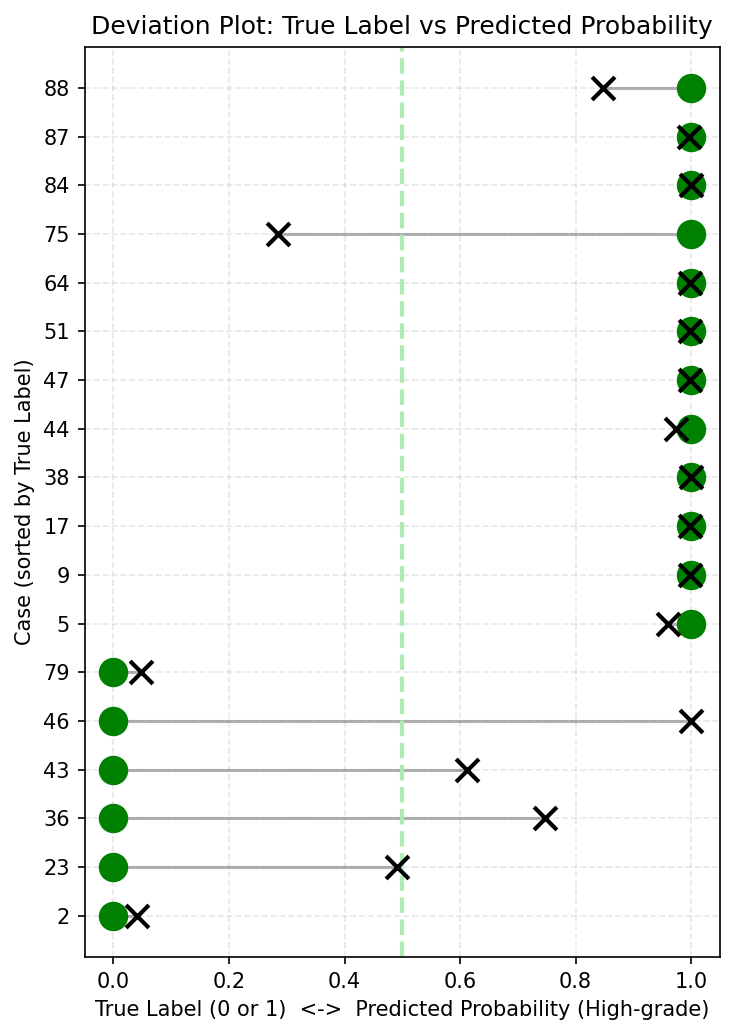

In [6]:
# Sort so true=0 cases appear first (optional but cleaner)
df_sorted = df.sort_values(["true_label", "case_id"]).reset_index(drop=True)
df_sorted["case_str"] = df_sorted["case_id"].astype(str)

plt.figure(figsize=(5,7), dpi=150)

for i, row in df_sorted.iterrows():
    # connecting line
    plt.plot(
        [row["true_label"], row["prob_high_grade"]],
        [i, i],
        color="gray",
        alpha=0.6,
        linewidth=1.5
    )

    # true label = large green circle
    plt.scatter(
        row["true_label"], i,
        color="green",
        s=200,
        marker="o",
        edgecolor="black",
        linewidth=0,
        zorder=3
    )

    # predicted probability = small black X
    plt.scatter(
        row["prob_high_grade"], i,
        color="black",
        s=120,
        marker="x",
        linewidths=2,
        zorder=4
    )

plt.yticks(range(len(df_sorted)), df_sorted["case_str"])
plt.axvline(0.5, color="#ADEBB3", linestyle="--", linewidth=2, label="Decision Threshold (0.5)")
plt.xlabel("True Label (0 or 1)  <->  Predicted Probability (High-grade)")
plt.ylabel("Case (sorted by True Label)")
plt.title("Deviation Plot: True Label vs Predicted Probability")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


4. Effective Attention Score Distribution: PATCHES

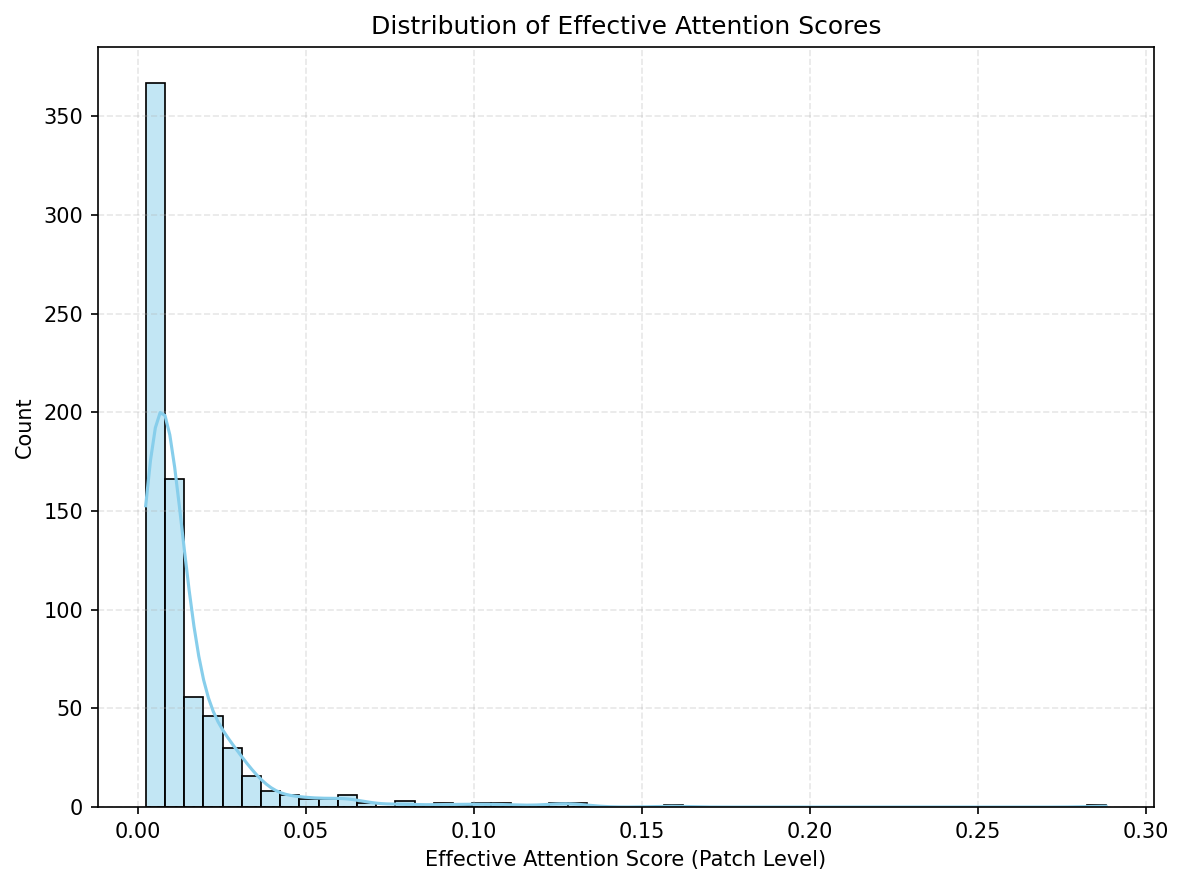

In [9]:
# read in top % effective attention for case
topeffect = pd.read_csv("top_effective_patches_per_case_5.0pct.csv")

# Plot histogram 

plt.figure(figsize=(8,6), dpi=150)
sns.histplot(
    topeffect['effective_weight'],
    bins=50,      # number of bins
    kde=True,     # show KDE curve
    color='skyblue',
    edgecolor='black'
)

plt.xlabel("Effective Attention Score (Patch Level)")
plt.ylabel("Count")
plt.title("Distribution of Effective Attention Scores")
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

5. attention score distribtion for slices

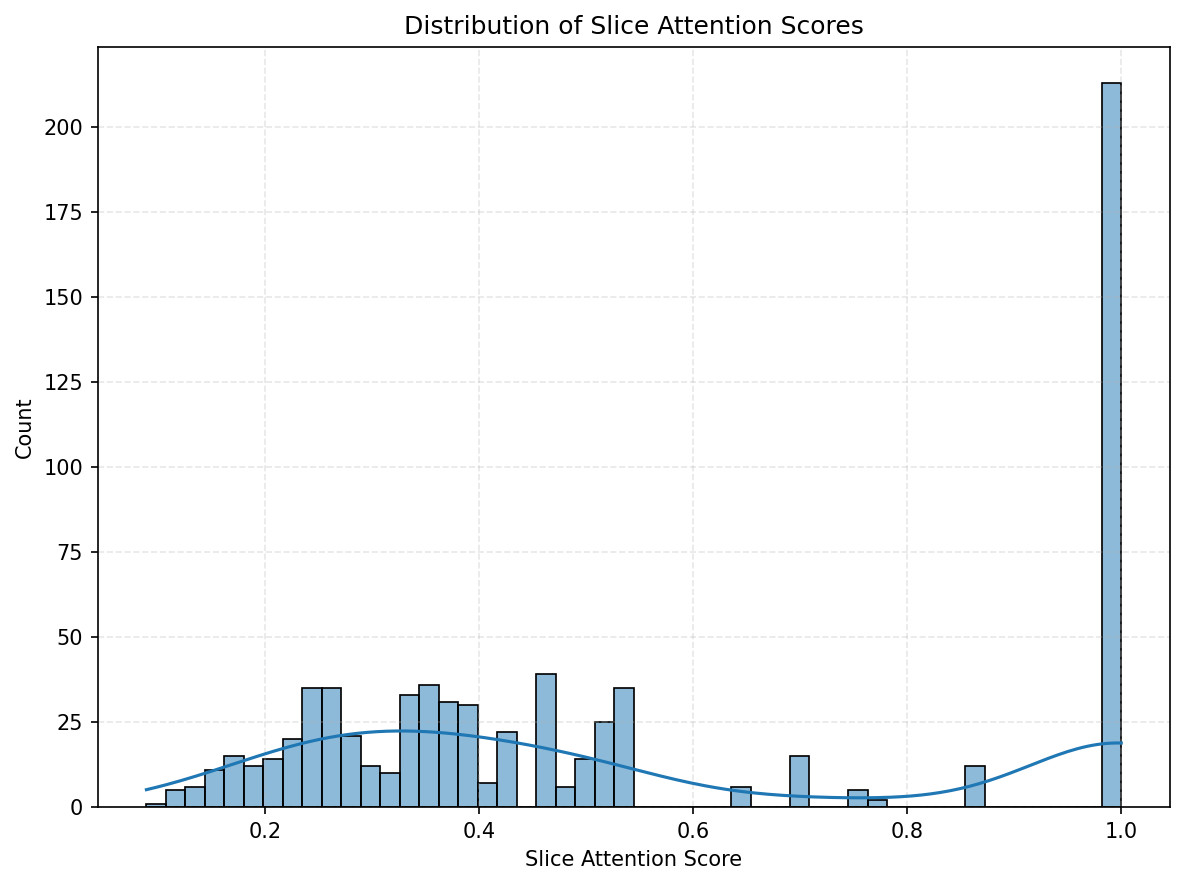

In [17]:
# read in top % effective attention for case
topeffect = pd.read_csv("top_effective_patches_per_case_5.0pct.csv")

# Plot histogram 
plt.figure(figsize=(8,6), dpi=150)

sns.histplot(
    topeffect["slice_attn_weight"],
    bins=50,
    kde=True,
    edgecolor="black"
)

plt.xlabel("Slice Attention Score")
plt.ylabel("Count")
plt.title("Distribution of Slice Attention Scores")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

6. attention score distribtion for stains

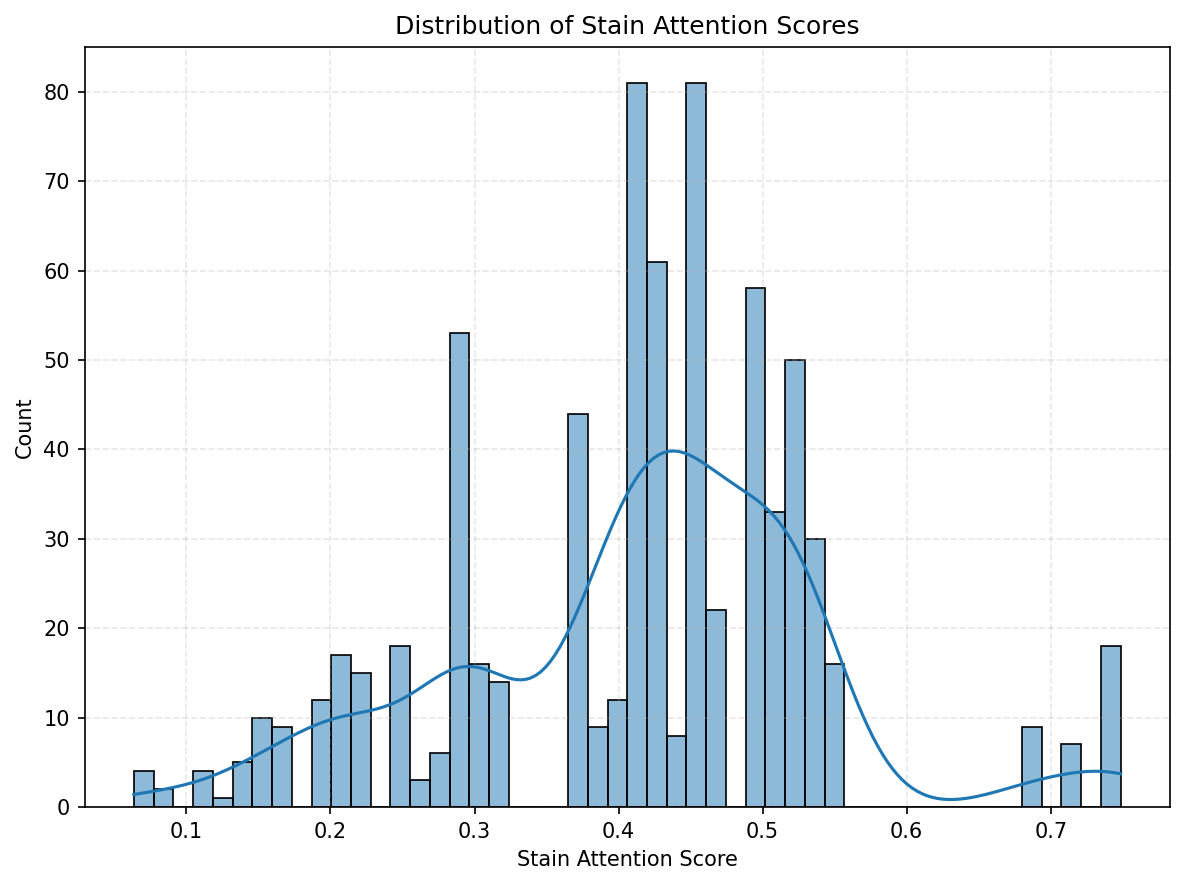

In [18]:
# read in top % effective attention for case
topeffect = pd.read_csv("top_effective_patches_per_case_5.0pct.csv")

# Plot histogram 
plt.figure(figsize=(8,6), dpi=150)

sns.histplot(
    topeffect["stain_attn_weight"],
    bins=50,
    kde=True,
    edgecolor="black"
)

plt.xlabel("Stain Attention Score")
plt.ylabel("Count")
plt.title("Distribution of Stain Attention Scores")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

7. top 10 high attention patches for correctly classified class (both benign & high grade)

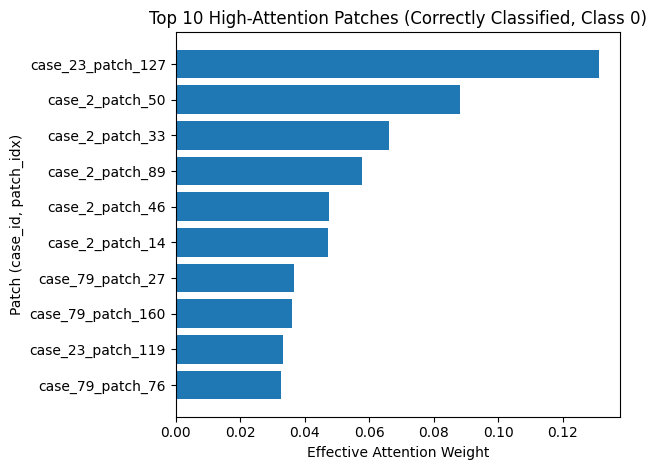

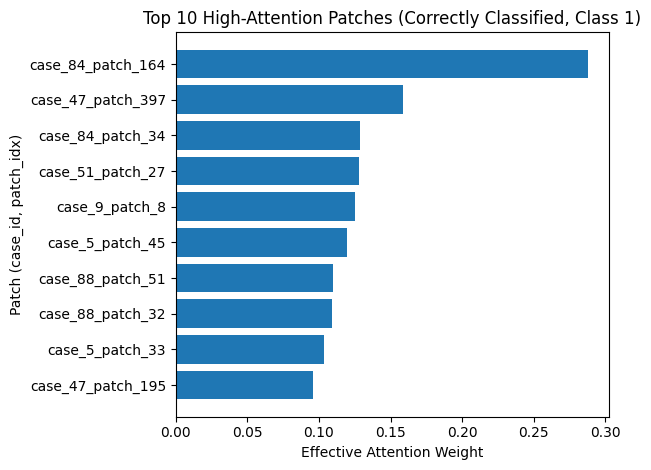

In [ ]:
# Load the data
df = pd.read_csv("top_effective_patches_per_case_5.0pct.csv")

# 1. Keep only correctly classified rows
correct = df[df["true_label"] == df["pred_label"]]

# 2. Get top 10 patches per class based on effective_weight
top10_per_class = (
    correct.sort_values("effective_weight", ascending=False)
           .groupby("true_label")
           .head(10)
)

# Optional: create a label for plotting
top10_per_class["patch_label"] = (
    "case_" + top10_per_class["case_id"].astype(str) +
    "_patch_" + top10_per_class["patch_idx"].astype(str)
)

# 3. Plot (one chart per class)
for label, subset in top10_per_class.groupby("true_label"):
    plt.figure()
    subset = subset.sort_values("effective_weight", ascending=True)

    plt.barh(subset["patch_label"], subset["effective_weight"])
    plt.title(f"Top 10 High-Attention Patches (Correctly Classified, Class {label})")
    plt.xlabel("Effective Attention Weight")
    plt.ylabel("Patch (case_id, patch_idx)")
    plt.tight_layout()
    plt.show()

8. top 10 low attention patches for correctly classified class (both benign & high grade)

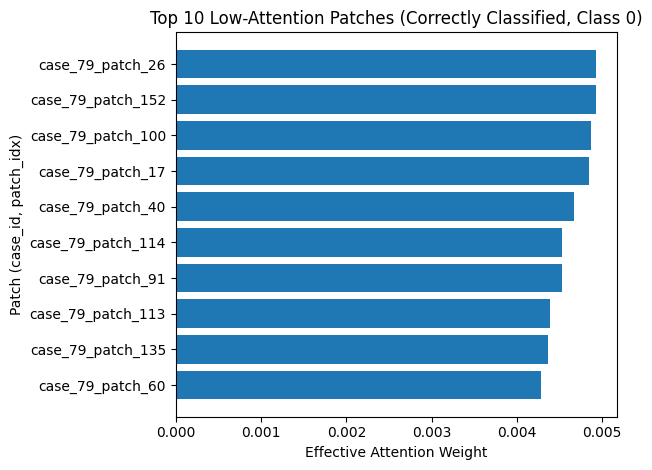

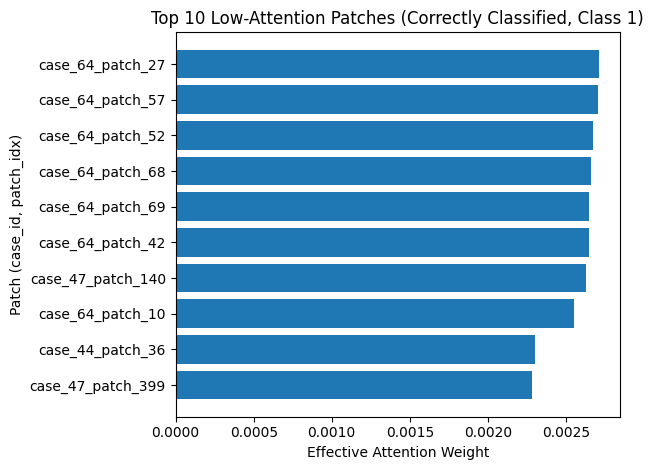

In [32]:
# Load data
df = pd.read_csv("top_effective_patches_per_case_5.0pct.csv")

# 1. Keep only correctly classified rows
correct = df[df["true_label"] == df["pred_label"]]

# 2. Get lowest 10 patches per class based on effective_weight
low10_per_class = (
    correct.sort_values("effective_weight", ascending=True)
           .groupby("true_label")
           .head(10)
)

# Optional: label for plotting
low10_per_class["patch_label"] = (
    "case_" + low10_per_class["case_id"].astype(str) +
    "_patch_" + low10_per_class["patch_idx"].astype(str)
)

# 3. Plot (one plot per class)
for label, subset in low10_per_class.groupby("true_label"):
    plt.figure()
    subset = subset.sort_values("effective_weight", ascending=True)

    plt.barh(subset["patch_label"], subset["effective_weight"])
    plt.title(f"Top 10 Low-Attention Patches (Correctly Classified, Class {label})")
    plt.xlabel("Effective Attention Weight")
    plt.ylabel("Patch (case_id, patch_idx)")
    plt.tight_layout()
    plt.show()


9. top 10 high attention patches for incorrectly classified class (both benign & high grade)

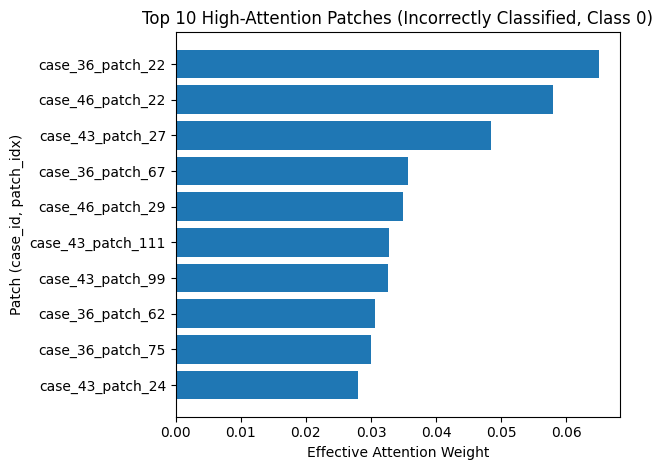

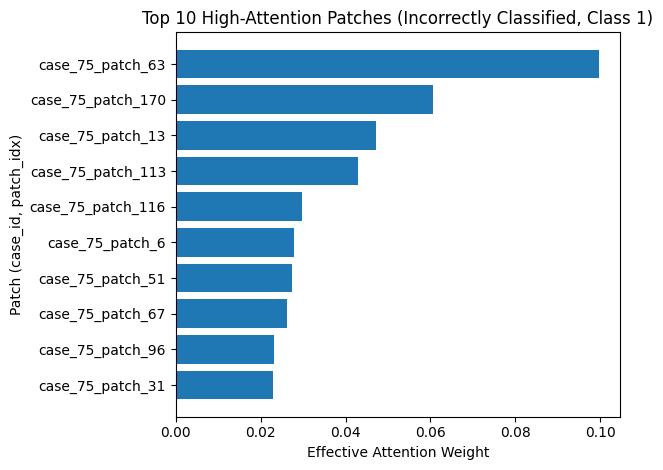

In [33]:
# Load data
df = pd.read_csv("top_effective_patches_per_case_5.0pct.csv")

# 1. Keep only incorrectly classified rows
incorrect = df[df["true_label"] != df["pred_label"]]

# 2. Get top 10 patches per class based on effective_weight
top10_incorrect = (
    incorrect.sort_values("effective_weight", ascending=False)
             .groupby("true_label")
             .head(10)
)

# Optional: create a label for plotting
top10_incorrect["patch_label"] = (
    "case_" + top10_incorrect["case_id"].astype(str) +
    "_patch_" + top10_incorrect["patch_idx"].astype(str)
)

# 3. Plot (one plot per true class)
for label, subset in top10_incorrect.groupby("true_label"):
    plt.figure()
    subset = subset.sort_values("effective_weight", ascending=True)

    plt.barh(subset["patch_label"], subset["effective_weight"])
    plt.title(f"Top 10 High-Attention Patches (Incorrectly Classified, Class {label})")
    plt.xlabel("Effective Attention Weight")
    plt.ylabel("Patch (case_id, patch_idx)")
    plt.tight_layout()
    plt.show()

10. top 10 low attention patches for incorrectly classified class (both benign & high grade)

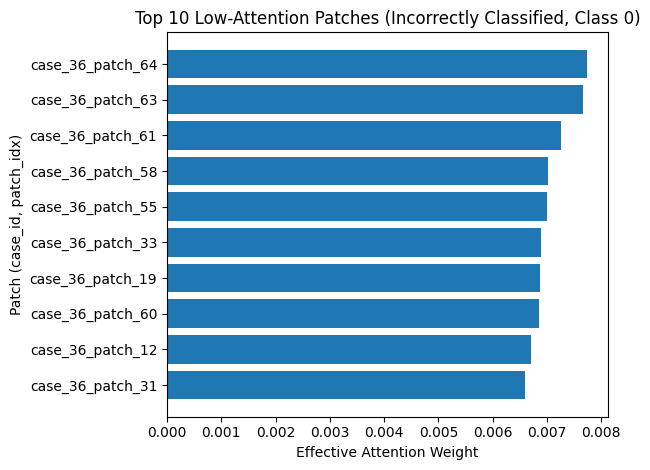

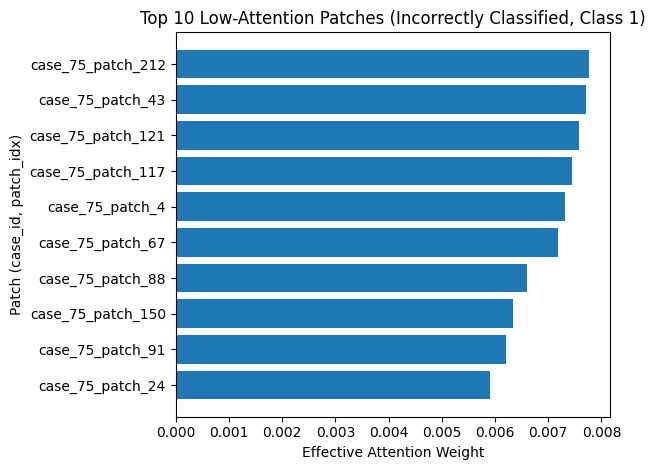

In [34]:
# Load data
df = pd.read_csv("top_effective_patches_per_case_5.0pct.csv")

# 1. Keep only incorrectly classified rows
incorrect = df[df["true_label"] != df["pred_label"]]

# 2. Get lowest 10 patches per class based on effective_weight
low10_incorrect = (
    incorrect.sort_values("effective_weight", ascending=True)
             .groupby("true_label")
             .head(10)
)

# Optional: create a label for plotting
low10_incorrect["patch_label"] = (
    "case_" + low10_incorrect["case_id"].astype(str) +
    "_patch_" + low10_incorrect["patch_idx"].astype(str)
)

# 3. Plot (one plot per true class)
for label, subset in low10_incorrect.groupby("true_label"):
    plt.figure()
    subset = subset.sort_values("effective_weight", ascending=True)

    plt.barh(subset["patch_label"], subset["effective_weight"])
    plt.title(f"Top 10 Low-Attention Patches (Incorrectly Classified, Class {label})")
    plt.xlabel("Effective Attention Weight")
    plt.ylabel("Patch (case_id, patch_idx)")
    plt.tight_layout()
    plt.show()